In [190]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter # This is a matplotlib tool the custom-formats axis numbers

file_path = "Integrated-Patient-Level-Activity-and-Costing-2021-22.csv"

df = pd.read_csv(file_path)

# light clean
df["BREAKDOWN_GROUP_1"] = df["BREAKDOWN_GROUP_1"].astype(str).str.strip()
df["BREAKDOWN_GROUP_2"] = df["BREAKDOWN_GROUP_2"].astype(str).str.strip()
df["ACTIVITY_COUNT"] = pd.to_numeric(df["ACTIVITY_COUNT"], errors="coerce")
df["TOTAL_COST"] = pd.to_numeric(df["TOTAL_COST"], errors="coerce")
df = df.dropna(subset=["ACTIVITY_COUNT", "TOTAL_COST"], how="all")

# focus only on Male / Female
gender_df = df[df["BREAKDOWN_GROUP_1"].isin(["Male", "Female"])].copy()

# age rows
age_df = gender_df[
    gender_df["BREAKDOWN_GROUP_2"].str.contains("years", case=False, na=False)
].copy()

# sorting age bands
def get_start_age(age_text: str) -> int:
    first = age_text.split("-")[0].split()[0]
    return int(first)

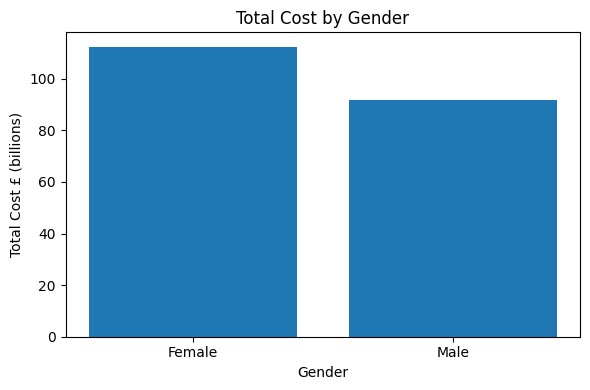

In [191]:
gender_cost = (
    gender_df.groupby("BREAKDOWN_GROUP_1")[["TOTAL_COST"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(6,4))
plt.bar(gender_cost["BREAKDOWN_GROUP_1"], gender_cost["TOTAL_COST"] /1e9) # 1e9 tells the number of zeros in this case 9
plt.title("Total Cost by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Cost £ (billions)")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}")) # reformats it to the appropriate decimal place on the x-axis
plt.tight_layout()
plt.show()

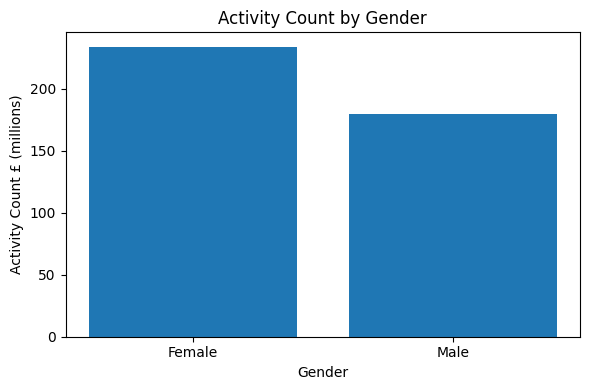

In [192]:
gender_activity = (
    gender_df
    .groupby("BREAKDOWN_GROUP_1")[["ACTIVITY_COUNT"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(6, 4))
plt.bar(gender_activity["BREAKDOWN_GROUP_1"], gender_activity["ACTIVITY_COUNT"] / 1e6) # 6 zeros
plt.title("Activity Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Activity Count £ (millions)")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}")) # to the decimal place
plt.tight_layout()
plt.show()

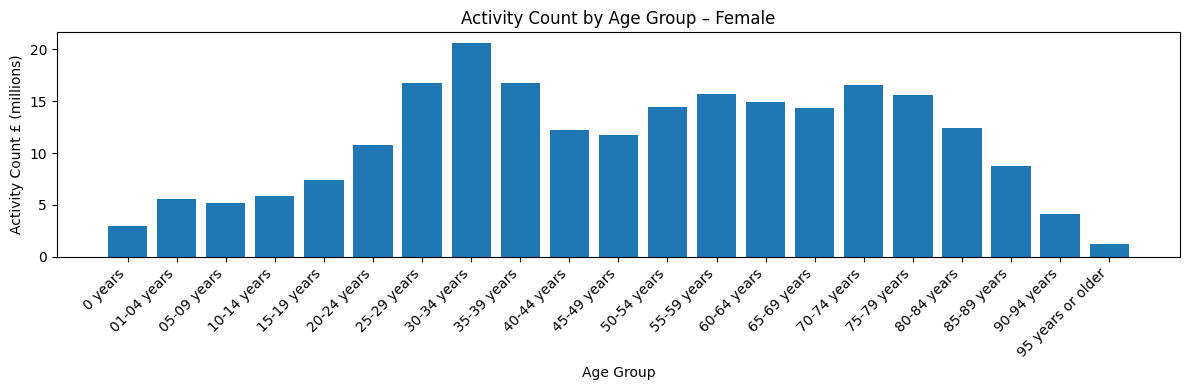

In [193]:
female_age = age_df[age_df["BREAKDOWN_GROUP_1"] == "Female"].copy()

female_age = (
    female_age
    .groupby("BREAKDOWN_GROUP_2")[["ACTIVITY_COUNT"]]
    .sum()
    .reset_index()
)

female_age["AGE_SORT"] = female_age ["BREAKDOWN_GROUP_2"].apply(get_start_age)
female_age = female_age.sort_values("AGE_SORT")

plt.figure(figsize=(12, 4))
plt.bar(female_age["BREAKDOWN_GROUP_2"], female_age["ACTIVITY_COUNT"]/ 1e6)
plt.title("Activity Count by Age Group – Female")
plt.xlabel("Age Group")
plt.ylabel("Activity Count £ (millions)")
plt.xticks(rotation=45, ha="right")

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

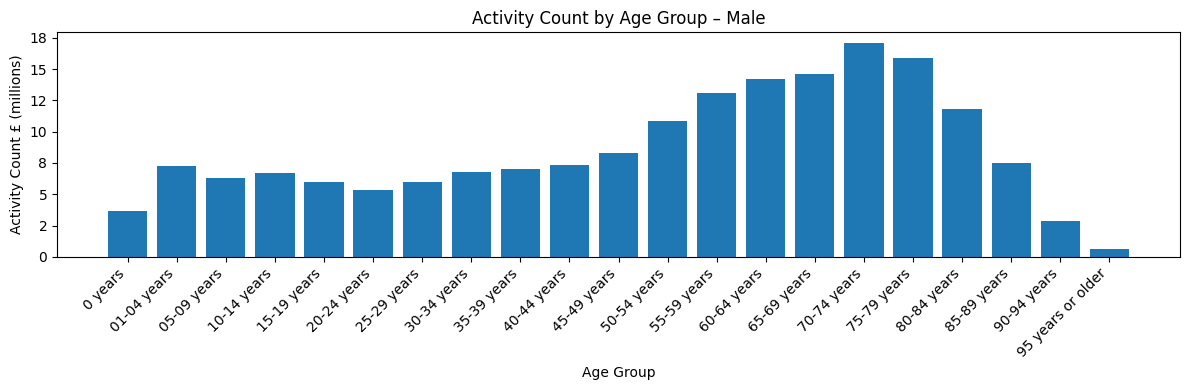

In [194]:
male_age = age_df[age_df["BREAKDOWN_GROUP_1"] == "Male"].copy()

male_age = (
    male_age
    .groupby("BREAKDOWN_GROUP_2")[["ACTIVITY_COUNT"]]
    .sum()
    .reset_index()
)

male_age ["AGE_SORT"] = male_age ["BREAKDOWN_GROUP_2"].apply(get_start_age)
male_age = male_age.sort_values("AGE_SORT")

plt.figure(figsize=(12, 4))
plt.bar(male_age ["BREAKDOWN_GROUP_2"], male_age ["ACTIVITY_COUNT"] / 1e6)
plt.title("Activity Count by Age Group – Male")
plt.xlabel("Age Group")
plt.ylabel("Activity Count £ (millions)")
plt.xticks(rotation=45, ha="right")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))
plt.tight_layout()
plt.show()